Text(0, 0.5, 'X2')

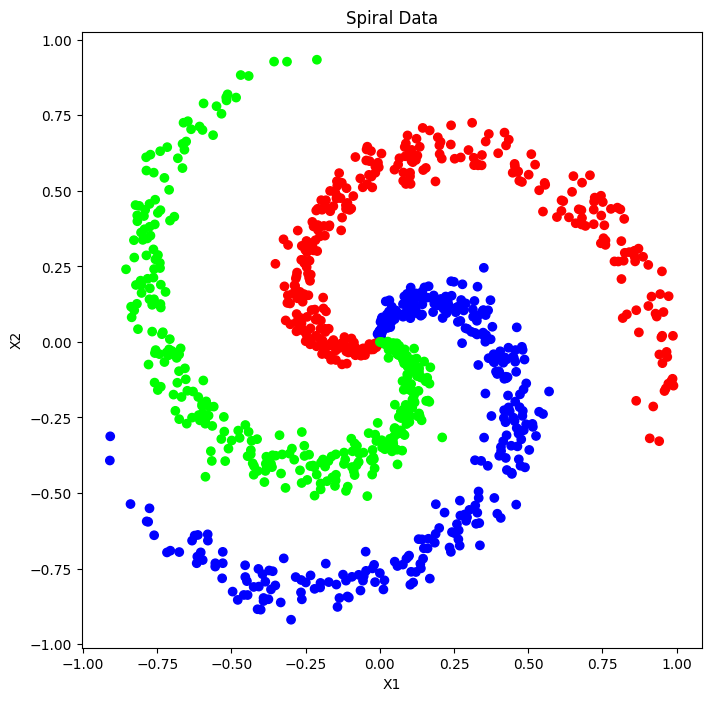

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore

def generate_spiral_data(n_points,n_classes):
    X=[]
    y=[]
    for class_number in range(n_classes):
        ix = range(n_points * class_number, (n_points * class_number +1))
        r = np.linspace(0.0,1,n_points) # radius 1
        t = np.linspace(class_number * 4,(class_number+1)* 4,n_points) + np.random.randn(n_points)*0.2 # theta
        X.extend(np.c_[r * np.sin(t),r * np.cos(t)])
        y.extend([class_number] * n_points)
    return np.array(X),np.array(y)

# generate spiral data
X,y = generate_spiral_data(333,3) # 999 points , classes

# plot the spiral data
plt.figure(figsize=(8,8))
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')



Epoch 1/50


c:\Users\sudsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4218 - loss: 1.0271 - val_accuracy: 0.5750 - val_loss: 0.9164
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5494 - loss: 0.8580 - val_accuracy: 0.5350 - val_loss: 0.7821
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5657 - loss: 0.7527 - val_accuracy: 0.5650 - val_loss: 0.7032
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5957 - loss: 0.6889 - val_accuracy: 0.6250 - val_loss: 0.6542
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6270 - loss: 0.6293 - val_accuracy: 0.6450 - val_loss: 0.5941
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7059 - loss: 0.5757 - val_accuracy: 0.8100 - val_loss: 0.5413
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7935 - loss: 0.5206 - val_accuracy: 0.8250 - val_loss: 0.5016
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8148 - loss: 0.4686 - val_accuracy: 0.8700 - val_loss: 0.4320
E

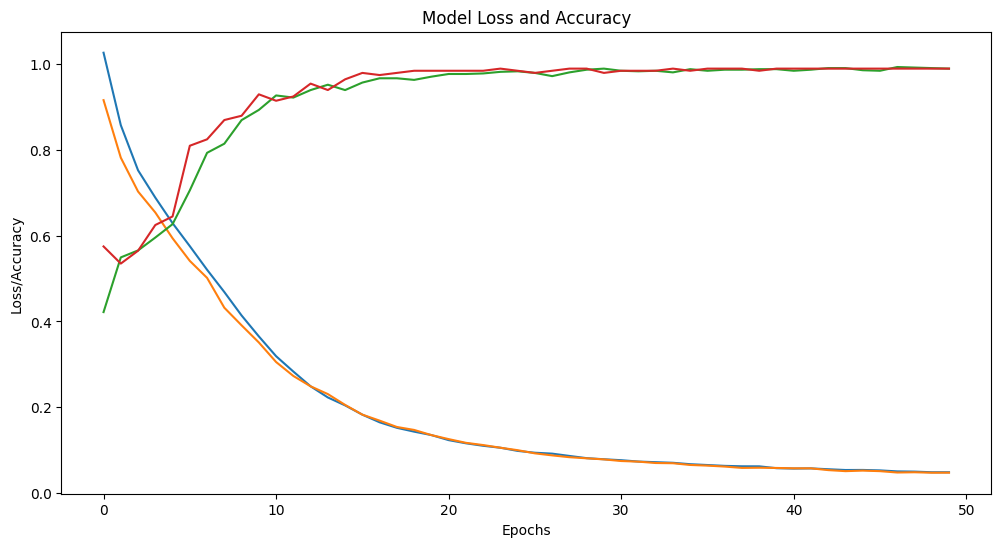

In [11]:
# Split the data into training and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Initialize the scalar
scalar = StandardScaler()

# Fit the scalar on the training data
scalar.fit(X_train)

# Transform the training and the test data
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

# Define the model
model = Sequential()
model.add(Dense(64,input_dim=2,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(3,activation='softmax'))

# Compile the model
# model.compile(optimizer=tf.keras.optimizers.SGD(),loss="sparse_categorical_crossentropy",metrics=['accuracy'])
model.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9),loss="sparse_categorical_crossentropy",metrics=['accuracy'])

# model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])

# Fit the model
history = model.fit(x=X_train_scaled,y=y_train,validation_data=(X_test_scaled,y_test),epochs=50,verbose=1)

# Plot the trainings history
plt.figure(figsize=[12,6])
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


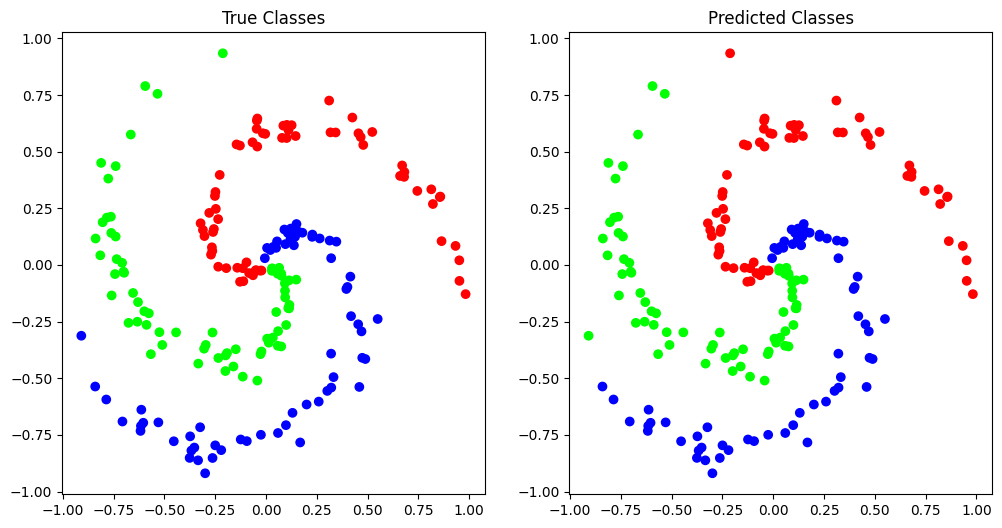

In [12]:
# Predict the class for test data
y_pred = np.argmax(model.predict(X_test_scaled),axis=1)

# Plot the comparison of predictions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='brg')
plt.title('True Classes')

plt.subplot(1,2,2)
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap='brg')
plt.title('Predicted Classes')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


C:\Users\sudsh\AppData\Local\Temp\ipykernel_18340\4161712753.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(new_point[:,0],new_point[:,1],c='yellow',edgecolors='black',s=100,label=f"New Point Prediction: {color_map} ",cmap='brg',alpha=0.5)


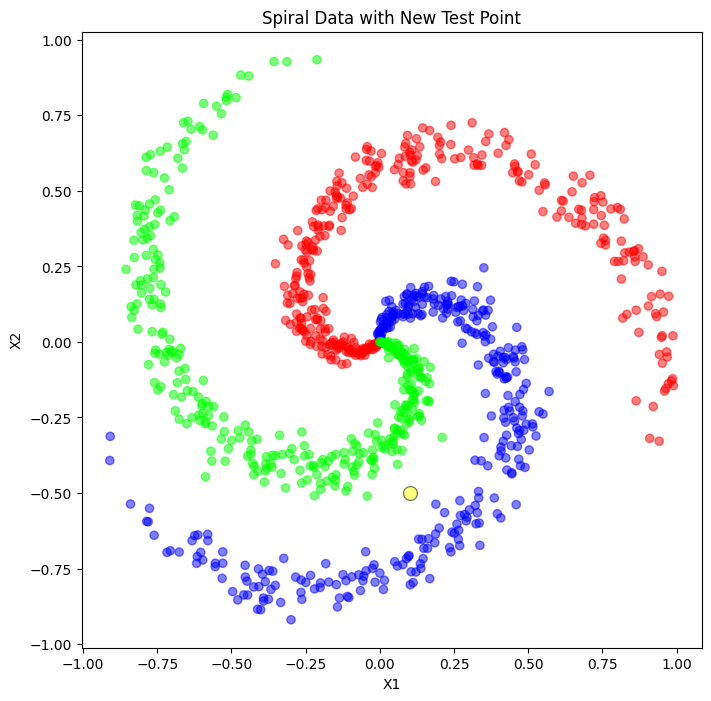

In [13]:
# New test point
new_point = np.array([[0.1,-0.5]])
new_point_scaled= scalar.transform(new_point)
new_pred = np.argmax(model.predict(new_point_scaled),axis=1)

# Color map for the legend
color_map = {0:'red',1:'green',2:'blue'}

# Plot the new test point prediction
plt.figure(figsize=(8,8))
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg',alpha=0.5)
plt.scatter(new_point[:,0],new_point[:,1],c='yellow',edgecolors='black',s=100,label=f"New Point Prediction: {color_map} ",cmap='brg',alpha=0.5)
plt.title('Spiral Data with New Test Point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()